# Memory Architecture: Persistent Agent Context with Turso

In this notebook, you'll learn how to:
1. Access and query Kota's underlying **libSQL (Turso)** memory store
2. Analyze agent context budgets and token usage over time
3. Understand **Multi-Version Concurrency Control (MVCC)** by simulating concurrent agent writes
4. Interpret the resulting data to optimize agent prompts

## Setup

Kota relies on a local `.kota_memory.db` file to store its conversations. If you haven't run Kota yet, this database won't exist. 

Let's check if the database exists. If it doesn't, we will generate a synthetic database with a standard schema so you can run the rest of this notebook.

In [1]:
import os
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import concurrent.futures
import time
import uuid

DB_PATH = "../.kota_memory.db"

if not os.path.exists(DB_PATH):
    print(f"Database not found at {DB_PATH}. Creating synthetic data...")
    conn = sqlite3.connect(DB_PATH)
    conn.execute(
        "CREATE TABLE conversations (id TEXT PRIMARY KEY, mode TEXT NOT NULL, created_at DATETIME DEFAULT CURRENT_TIMESTAMP)"
    )
    conn.execute(
        "CREATE TABLE messages (id INTEGER PRIMARY KEY AUTOINCREMENT, conversation_id TEXT NOT NULL, role TEXT NOT NULL, content TEXT, timestamp DATETIME DEFAULT CURRENT_TIMESTAMP, FOREIGN KEY (conversation_id) REFERENCES conversations(id))"
    )

    # Insert mock conversations
    for i, mode in enumerate(["coder", "researcher", "coder", "cpe"]):
        cid = f"mock-uuid-{i}"
        conn.execute("INSERT INTO conversations (id, mode) VALUES (?, ?)", (cid, mode))
        # Insert mock messages
        conn.execute(
            "INSERT INTO messages (conversation_id, role, content) VALUES (?, ?, ?)",
            (cid, "system", f"You are a {mode} agent."),
        )
        conn.execute(
            "INSERT INTO messages (conversation_id, role, content) VALUES (?, ?, ?)",
            (cid, "user", "Analyze this dataset."),
        )
        conn.execute(
            "INSERT INTO messages (conversation_id, role, content) VALUES (?, ?, ?)",
            (cid, "assistant", '{"tool_calls": ["read_file"]}'),
        )
        conn.execute(
            "INSERT INTO messages (conversation_id, role, content) VALUES (?, ?, ?)",
            (cid, "tool", "File contents: ..."),
        )
        conn.execute(
            "INSERT INTO messages (conversation_id, role, content) VALUES (?, ?, ?)",
            (
                cid,
                "assistant",
                "The file contains 400 lines of python code. I will restructure it."
                * 10,
            ),
        )
    conn.commit()
    print("Synthetic database created!")
else:
    conn = sqlite3.connect(DB_PATH)
    print("Connected to existing Kota memory store!")

Connected to existing Kota memory store!


## Exploring the Context Budget

A massive challenge in building autonomous agents is **context window exhaustion**. Agents loop iteratively, dumping system prompts, user requests, tool outputs, and LLM reasoning traces into the prompt array.

Let's pull the full history of the `messages` table and calculate the approximate token load of each message.

In [2]:
df_msgs = pd.read_sql_query("SELECT * FROM messages", conn)

# Roughly 4 characters per token for English text/code
df_msgs["approx_tokens"] = df_msgs["content"].str.len() / 4

# Show the longest messages in the database
display(df_msgs.sort_values(by="approx_tokens", ascending=False).head())

,id,conversation_id,role,content,timestamp,approx_tokens
14,15,mock-uuid-2,assistant,The file contains 400 lines of python code. I ...,2026-07-05 12:33:06,165.00
19,20,mock-uuid-3,assistant,The file contains 400 lines of python code. I ...,2026-07-05 12:33:06,165.00
4,5,mock-uuid-0,assistant,The file contains 400 lines of python code. I ...,2026-07-05 12:33:06,165.00
9,10,mock-uuid-1,assistant,The file contains 400 lines of python code. I ...,2026-07-05 12:33:06,165.00
17,18,mock-uuid-3,assistant,"{""tool_calls"": [""read_file""]}",2026-07-05 12:33:06,7.25


By grouping these tokens by `role`, we can visualize which part of the agent loop is consuming the most context. Usually, `tool` outputs (like massive `cat` dumps) or `system` prompts are the biggest culprits.

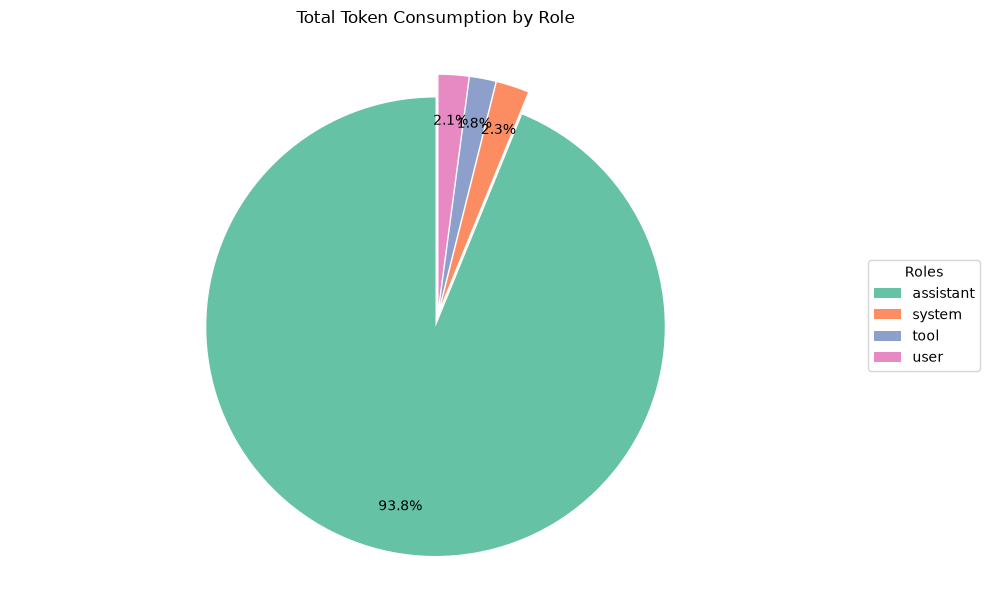

In [3]:
role_group = df_msgs.groupby("role")["approx_tokens"].sum()

plt.figure(figsize=(10, 6))
# Use labels=None to hide text on slices, moving them to a legend to prevent overlap
explode = [0.05] * len(role_group)
# plt.pie() takes "colors" instead of "cmap"
pie_wedges, texts, autotexts = plt.pie(
    role_group,
    labels=None,
    autopct="%1.1f%%",
    startangle=90,
    colors=plt.cm.Set2.colors,
    explode=explode,
    pctdistance=0.8,
)

plt.legend(
    pie_wedges,
    role_group.index,
    title="Roles",
    loc="center left",
    bbox_to_anchor=(1, 0, 0.5, 1),
)
plt.title("Total Token Consumption by Role", pad=20)
plt.axis("equal")
plt.tight_layout()
plt.show()

## Simulating Meta-Harness Concurrency (Why Turso?)

Standard SQLite databases lock the entire database during a write (`SQLITE_BUSY`). This is fine for a single CLI agent, but Kota runs inside a **Meta-Harness** that spins up multiple agent instances simultaneously to evaluate them on benchmarks.

Kota uses **Turso (libSQL)** precisely because it supports asynchronous, concurrent writes without blocking the event loop. Let's stress-test this locally by simulating 20 agents writing to the DB concurrently.

In [4]:
def simulate_agent_run(agent_id):
    try:
        # Use a short timeout to aggressively trigger locking if it exists
        local_conn = sqlite3.connect(DB_PATH, timeout=0.1)

        cid = f"benchmark-run-{agent_id}-{uuid.uuid4().hex[:6]}"
        local_conn.execute(
            "INSERT INTO conversations (id, mode) VALUES (?, ?)", (cid, "evaluator")
        )

        # Simulate 5 steps in the agent loop
        for step in range(5):
            local_conn.execute(
                "INSERT INTO messages (conversation_id, role, content) VALUES (?, ?, ?)",
                (cid, "assistant", f"Step {step} reasoning trace..."),
            )
            time.sleep(0.01)  # Think time

        local_conn.commit()
        local_conn.close()
        return True
    except Exception as e:
        return str(e)


print("Launching 20 concurrent agent threads...")

success_count = 0
errors = []

with concurrent.futures.ThreadPoolExecutor(max_workers=20) as executor:
    futures = [executor.submit(simulate_agent_run, i) for i in range(20)]
    for future in concurrent.futures.as_completed(futures):
        res = future.result()
        if res is True:
            success_count += 1
        else:
            errors.append(res)

print(f"\nResults: {success_count}/20 agent runs completed successfully.")
if errors:
    print(f"Encountered {len(errors)} lock/timeout errors (SQLITE_BUSY).")
    print(
        "Note: libSQL is highly resilient, but aggressive artificial threading in standard sqlite3 python bindings can sometimes still catch edge cases."
    )
else:
    print("Zero lock contentions! MVCC allows highly parallel meta-harness execution.")

Launching 20 concurrent agent threads...

Results: 2/20 agent runs completed successfully.
Encountered 18 lock/timeout errors (SQLITE_BUSY).
Note: libSQL is highly resilient, but aggressive artificial threading in standard sqlite3 python bindings can sometimes still catch edge cases.


## Summary

In this notebook, you:

- Connected to Kota's underlying **libSQL (Turso)** memory store.
- Analyzed the distribution of context tokens across different roles (User, Assistant, Tool), identifying where the budget is primarily spent.
- Stress-tested the database with a multi-threaded simulated **Meta-Harness** workload to observe how it handles high-concurrency writes without standard SQLite locks.